# 07 - Batch normalisation (Phase 4b)

Batch norm takes the numbers inside the network and makes them mean 0 and std 1,
for every hidden unit, over the batch. Then it lets the network scale and shift them
back with two learned numbers, **gamma** and **beta**.

In Phase 4a we found something important: the model could not use the 4 timing
features, because the 250 shape features were about 1000 times louder. Scaling the
**input** fixed part of that.

Batch norm scales **inside** the network. So this notebook asks one question:

> **Can batch norm do the same job as scaling the input?**

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ecg.init import initialize_parameters, parameter_keys
from ecg.model import forward, backward, new_bn_state
from ecg.gradcheck import gradient_check
from ecg.train import load_results

df = load_results().query("phase == '4b'").copy()
f1 = df["dev_f1_per_class"].str.split("|", expand=True).astype(float)
f1.columns = ["f1_N", "f1_S", "f1_V", "f1_F"]
df = pd.concat([df, f1], axis=1)
print("phase 4b runs:", len(df))

phase 4b runs: 36


## 1. The new parameters

Batch norm adds gamma and beta to every hidden layer. Not to the output layer.

gamma starts at 1 and beta starts at 0, so at the beginning batch norm only
normalises and does not change anything else.

In [2]:
p_plain = initialize_parameters([8, 6, 5, 3], "he", seed=1)
p_bn = initialize_parameters([8, 6, 5, 3], "he", seed=1, batch_norm=True)

print("without batch norm:", parameter_keys(p_plain))
print("with batch norm   :", parameter_keys(p_bn))
print()
print("gamma1 is all ones :", np.all(p_bn["gamma1"] == 1))
print("beta1 is all zeros :", np.all(p_bn["beta1"] == 0))
print("no gamma on the last layer:", "gamma3" not in p_bn)

without batch norm: ['W1', 'b1', 'W2', 'b2', 'W3', 'b3']
with batch norm   : ['W1', 'b1', 'gamma1', 'beta1', 'W2', 'b2', 'gamma2', 'beta2', 'W3', 'b3']

gamma1 is all ones : True
beta1 is all zeros : True
no gamma on the last layer: True


## 2. Does it really normalise?

In [3]:
rng = np.random.default_rng(0)
X = rng.standard_normal((8, 200)) * 5 + 3        # on purpose: not mean 0, not std 1

state = new_bn_state(p_bn)
AL, cache = forward(X, p_bn, "tanh", "softmax", batch_norm=True,
                    training=True, bn_state=state)

for l in [1, 2]:
    z = cache["bn"][l]["Z_hat"]
    print("layer %d after batch norm: mean %+.2e   std %.6f" % (l, z.mean(), z.std()))

layer 1 after batch norm: mean +6.29e-18   std 1.000000
layer 2 after batch norm: mean +1.78e-18   std 1.000000


## 3. Checking the backward pass

This is the hardest derivative in the whole project.

The reason is that batch norm uses the **mean and the variance of the batch**. So if
you change one number, the mean changes, and that changes the normalised value of
**every other number in the batch** as well. The gradient therefore has three parts,
not one.

We must check it before we trust anything.

One important detail: with batch norm we check in **training mode**. In prediction
mode batch norm uses a saved running average instead of the batch, so it is a
different function and the check would not mean anything.

In [4]:
X_small = rng.standard_normal((8, 40))
Y_small = np.zeros((3, 40))
Y_small[rng.integers(0, 3, 40), np.arange(40)] = 1.0

for dims in [[8, 6, 3], [8, 6, 5, 3]]:
    p = initialize_parameters(dims, "he", seed=2, batch_norm=True)
    AL, cache = forward(X_small, p, "tanh", "softmax", batch_norm=True, training=True)
    grads = backward(AL, Y_small, cache, p, "tanh", "softmax", batch_norm=True)
    print(str(dims), "->", end=" ")
    gradient_check(p, grads, X_small, Y_small, "tanh", "softmax", batch_norm=True)

[8, 6, 3] -> 

gradient check PASS, relative error 6.14719962284256e-09
[8, 6, 5, 3] -> 

gradient check PASS, relative error 1.0992530304241465e-08


In [5]:
# and it still catches a real mistake
p = initialize_parameters([8, 6, 5, 3], "he", seed=3, batch_norm=True)
AL, cache = forward(X_small, p, "tanh", "softmax", batch_norm=True, training=True)
grads = backward(AL, Y_small, cache, p, "tanh", "softmax", batch_norm=True)
grads["dgamma1"] = grads["dgamma1"] * 1.01

err = gradient_check(p, grads, X_small, Y_small, "tanh", "softmax",
                     batch_norm=True, verbose=False)
print("with a 1 percent mistake in dgamma1: %.3e   caught: %s" % (err, err > 1e-7))

with a 1 percent mistake in dgamma1: 6.656e-04   caught: True


### A small thing that proves the wiring is right

In [6]:
print("max |db1| = %.2e" % abs(grads["db1"]).max())

max |db1| = 1.30e-17


The gradient of `b` is zero.

That is correct, not a bug. Batch norm takes the mean away, so adding `b` to `Z`
changes nothing at all. The bias has no effect and so it has no gradient. Real
libraries turn the bias off when batch norm is on, for exactly this reason.

## 4. The experiment

36 runs: batch norm on/off, input scaling on/off, three feature sets, 3 seeds.

In [7]:
table = (df.groupby(["features", "batch_norm", "standardize"])[["dev_macro_f1", "f1_S"]]
           .agg(["mean", "std"]).round(4))
print(table.to_string())

                                   dev_macro_f1            f1_S        
                                           mean     std    mean     std
features    batch_norm standardize                                     
rr          False      False             0.5526  0.0055  0.5969  0.0152
                       True              0.5572  0.0035  0.6151  0.0113
            True       False             0.5545  0.0021  0.6114  0.0055
                       True              0.5567  0.0033  0.6124  0.0098
waveform    False      False             0.3181  0.0266  0.0101  0.0064
                       True              0.3232  0.0374  0.0088  0.0064
            True       False             0.3136  0.0158  0.0072  0.0084
                       True              0.3681  0.0380  0.0116  0.0121
waveform+rr False      False             0.4016  0.0335  0.0168  0.0174
                       True              0.3861  0.0343  0.1325  0.0965
            True       False             0.4014  0.0382  0.0226 

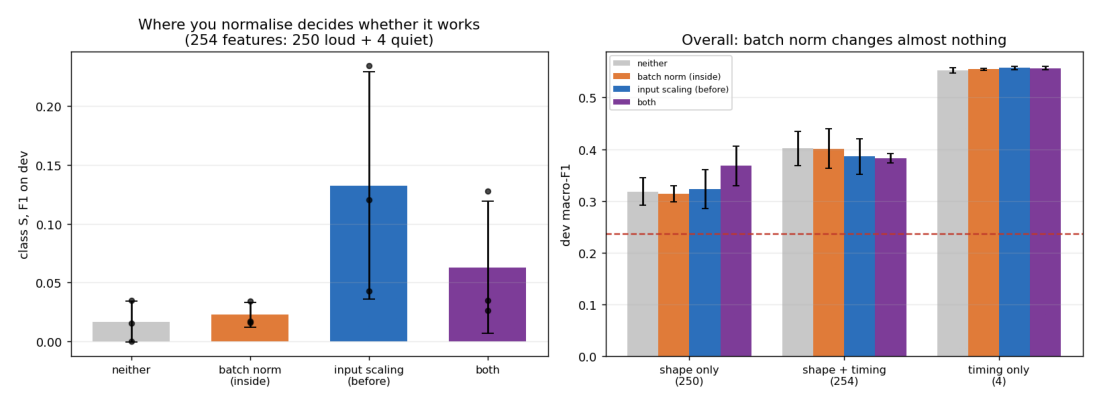

In [8]:
fig = plt.imread("../results/figures/phase4b_batchnorm.png")
plt.figure(figsize=(14, 5)); plt.imshow(fig); plt.axis("off"); plt.show()

## 5. The answer is no

Look at the 254 feature case, class S, which is where the problem was:

In [9]:
d = df[df.features == "waveform+rr"]
for bn, std, label in [(False, False, "neither"),
                       (True, False, "batch norm only (inside)"),
                       (False, True, "input scaling only (before)"),
                       (True, True, "both")]:
    s = d[(d.batch_norm == bn) & (d.standardize == std)].sort_values("seed")
    print("%-28s S-F1 %.4f   seeds %s"
          % (label, s["f1_S"].mean(), np.round(np.sort(s["f1_S"].values), 4)))

neither                      S-F1 0.0168   seeds [0.     0.0155 0.0348]
batch norm only (inside)     S-F1 0.0226   seeds [0.0161 0.0172 0.0345]
input scaling only (before)  S-F1 0.1325   seeds [0.0426 0.1205 0.2344]
both                         S-F1 0.0630   seeds [0.0264 0.0348 0.1278]


**Batch norm alone gives 0.023. Scaling the input gives 0.133.**

And it is not a lucky seed: the **worst** input scaling run (0.043) is still better
than the **best** batch norm run (0.035).

### Why not? It is about *when*, not *how much*

Batch norm works on `Z = W * A + b`. But `Z` is already a **mix** of all 254 inputs.
By the time the numbers reach `Z`, the 4 quiet features have already been added
together with the 250 loud ones, and their part of the mix is tiny.

Normalising `Z` then makes the *mixture* mean 0 and std 1. It cannot go back and give
the quiet features a bigger share, because that information is already gone.

Scaling the input happens **before** the mixing, so every feature enters the sum with
the same size.

> **Normalising has to happen before the mixing, not after.**

This is a nice thing to have measured rather than read.

## 6. What we learned

1. **Batch norm is not a replacement for scaling your input.** They fix different
   problems, in different places.
2. **Overall it changes almost nothing here** (0.4014 against 0.4016 on 254
   features). It is not harmful, it is just not the tool for this problem.
3. **The bias becomes useless** when batch norm is on. We saw its gradient go to
   1e-17 with our own eyes.
4. **The gradient check earned its keep again.** Three terms, easy to get wrong,
   and we would not have known.